# Spotify Genre Classification – Machine Learning Modeling

In this notebook, we develop and evaluate supervised machine learning models for the Spotify genre classification task.

Following the project guidelines, a stratified subset of 20,000 tracks is used to reduce computational cost while preserving the original genre distribution. Several classifiers are trained and compared to identify the model that achieves the best predictive performance.

## Load the Dataset and Define the Input and Target Variables

The processed dataset is loaded and divided into the input features (**X**) and the target variable (**Y**). The numerical audio features are used as model inputs, while **`track_genre`** serves as the target label for the multiclass classification task.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

In [2]:
root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
local_data_path = root / 'data' / 'spotify_genre_classification.csv'

if local_data_path.exists():
    data_path = local_data_path
else:
    dataset_path = Path(kagglehub.dataset_download('thedevastator/spotify-tracks-genre-dataset'))
    csv_files = sorted(dataset_path.rglob('*.csv'))

    if len(csv_files) == 0:
        raise FileNotFoundError('No CSV files were found in the downloaded Kaggle dataset.')

    data_path = csv_files[0]

print('Path to dataset file:', data_path)

df = pd.read_csv(data_path)
df.head()

Path to dataset file: /Users/enolariasalvarez/.cache/kagglehub/datasets/thedevastator/spotify-tracks-genre-dataset/versions/1/train.csv


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [3]:
target_name = 'track_genre'
Y = df[target_name]

numeric_names = df.select_dtypes(include=np.number).columns.tolist()
drop_names = ['Unnamed: 0']
feature_names = [name for name in numeric_names if name not in drop_names]

X = df[feature_names].values

print('Features:', feature_names)
print('X shape:', X.shape)
print('Y shape:', Y.shape)

Features: ['popularity', 'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']
X shape: (114000, 14)
Y shape: (114000,)


## Create a Stratified Subsample

A stratified random sample of 20,000 observations is created from the original dataset to reduce computational cost while preserving the class distribution.

Stratified sampling ensures that each genre remains approximately represented in the same proportion as in the full dataset.

In [4]:
n_samples = min(20000, df.shape[0])

df_sub, _ = train_test_split(
    df,
    train_size=n_samples,
    stratify=df[target_name],
    random_state=0
)

print('Subset size:', df_sub.shape)

Subset size: (20000, 21)


In [5]:
X = df_sub[feature_names].values
Y = df_sub[target_name].values

print('X shape:', X.shape)
print('Y shape:', Y.shape)

X shape: (20000, 14)
Y shape: (20000,)


## Split the Data into Training and Test Sets

The dataset is divided into separate training and test sets. The training set is used to fit the machine learning models, while the test set is reserved for evaluating their performance on previously unseen data.

A stratified split is applied to preserve the original genre distribution in both subsets.

In [6]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.25,
    stratify=Y,
    random_state=0
)

print('Training set:', X_train.shape, Y_train.shape)
print('Test set:', X_test.shape, Y_test.shape)

Training set: (15000, 14) (15000,)
Test set: (5000, 14) (5000,)


## Standardize the Input Features

The numerical input features are standardized to ensure they have comparable scales before training the machine learning models.

Feature scaling is required for classifiers such as **Logistic Regression** and **K-Nearest Neighbors**, which rely on optimization algorithms or distance calculations. In contrast, **Random Forest** is scale-invariant and is therefore trained using the original feature values.

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Train a Baseline Classifier

A **Dummy Classifier** is trained to establish a baseline level of performance. This classifier always predicts the most frequent class in the training data, without learning any relationships between the input features and the target variable.

Any machine learning model should outperform this baseline to demonstrate that it has learned meaningful patterns from the data.

In [8]:
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, Y_train)

Y_pred = baseline.predict(X_test)
baseline_acc = accuracy_score(Y_test, Y_pred)

print('Baseline accuracy:', baseline_acc)

Baseline accuracy: 0.0088


## Train and Compare Multiple Classifiers

Several supervised machine learning classifiers are trained and evaluated on the same training and test sets. Comparing models with different learning principles allows us to assess which approach is most suitable for the Spotify genre classification task.

The classifiers are evaluated using the same experimental setup to ensure a fair comparison of their predictive performance.

In [9]:
results = []

trained_models = {}

# Models that NEED scaling
scaled_models = [
    ('Logistic regression', LogisticRegression(max_iter=1000)),
    ('K-nearest neighbors', KNeighborsClassifier(n_neighbors=5))
]

for name, clf in scaled_models:
    print(name)
    clf.fit(X_train_scaled, Y_train)

    # Guardar el modelo entrenado
    trained_models[name] = clf

    preds = clf.predict(X_test_scaled)
    acc = accuracy_score(Y_test, preds)

    results.append((name, acc))
    print("accuracy:", acc)
    print()

# Random Forest
print("Random forest")

rf = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)
rf.fit(X_train, Y_train)

trained_models["Random forest"] = rf

rf_preds = rf.predict(X_test)
rf_acc = accuracy_score(Y_test, rf_preds)

results.append(("Random forest", rf_acc))
print("accuracy:", rf_acc)

Logistic regression
accuracy: 0.188

K-nearest neighbors
accuracy: 0.1442

Random forest
accuracy: 0.2918


In [10]:

results_df = pd.DataFrame(results, columns=['classifier', 'accuracy'])
results_df = results_df.sort_values(by='accuracy', ascending=False)

display(results_df)

,classifier,accuracy
2,Random forest,0.2918
0,Logistic regression,0.1880
1,K-nearest neighbors,0.1442


## Evaluate the Best-Performing Classifier

The classifier with the highest test accuracy is selected for a more detailed evaluation.

Its performance is analyzed using the classification report and confusion matrix, providing class-level precision, recall, and F1-score in addition to the overall accuracy.

In [11]:
validation_results = {}

for name, model in trained_models.items():

    if name in ["Logistic regression", "K-nearest neighbors"]:
        scores = cross_val_score(
            model,
            X_train_scaled,
            Y_train,
            cv=5,
            scoring="accuracy"
        )
    else:
        scores = cross_val_score(
            model,
            X_train,
            Y_train,
            cv=5,
            scoring="accuracy"
        )

    validation_results[name] = scores.mean()

    print(name)
    print("Mean validation accuracy:", scores.mean())
    print("Standard deviation:", scores.std())
    print()

    best_name = max(
    validation_results,
    key=validation_results.get
)

best_model = trained_models[best_name]

if best_name in ["Logistic regression", "K-nearest neighbors"]:
    Y_pred = best_model.predict(X_test_scaled)
else:
    Y_pred = best_model.predict(X_test)

best_acc = accuracy_score(Y_test, Y_pred)

print("Best classifier:", best_name)
print("Test accuracy:", best_acc)

Logistic regression
Mean validation accuracy: 0.18746666666666667
Standard deviation: 0.004964764736509568

K-nearest neighbors
Mean validation accuracy: 0.14806666666666665
Standard deviation: 0.006574022952331227

Random forest
Mean validation accuracy: 0.2866
Standard deviation: 0.005152777029050562

Best classifier: Random forest
Test accuracy: 0.2918


In [12]:
evaluation_results = {}

for name, model in trained_models.items():

    if name in ["Logistic regression", "K-nearest neighbors"]:
        preds = model.predict(X_test_scaled)
    else:
        preds = model.predict(X_test)

    acc = accuracy_score(Y_test, preds)
    evaluation_results[name] = (model, preds, acc)

best_name = max(evaluation_results, key=lambda x: evaluation_results[x][2])

best_model, Y_pred, best_acc = evaluation_results[best_name]

print("Best classifier:", best_name)
print("Accuracy:", best_acc)

Best classifier: Random forest
Accuracy: 0.2918


Although the best-performing model achieves an accuracy of approximately **29.18%**, this result should be interpreted in the context of the problem. The task requires distinguishing among **114 balanced genre classes**, making it substantially more challenging than conventional binary classification problems.

The results indicate that the evaluated models are able to learn meaningful relationships between the audio features and the target variable, with Random Forest providing the best overall predictive performance.

In [13]:
print(classification_report(Y_test, Y_pred))

                   precision    recall  f1-score   support

         acoustic       0.15      0.16      0.15        44
         afrobeat       0.34      0.30      0.32        44
         alt-rock       0.17      0.09      0.12        44
      alternative       0.21      0.23      0.22        44
          ambient       0.28      0.32      0.30        44
            anime       0.08      0.05      0.06        43
      black-metal       0.57      0.55      0.56        44
        bluegrass       0.38      0.55      0.45        44
            blues       0.23      0.07      0.11        44
           brazil       0.12      0.09      0.10        44
        breakbeat       0.58      0.41      0.48        44
          british       0.08      0.07      0.07        44
         cantopop       0.26      0.26      0.26        43
    chicago-house       0.36      0.36      0.36        44
         children       0.40      0.41      0.40        44
            chill       0.26      0.25      0.25       

Accuracy measures the proportion of correctly classified tracks. To obtain a more detailed evaluation, the classification report also provides **precision**, **recall**, and **F1-score** for each genre.

- **Precision**: the proportion of correct predictions among all tracks assigned to a given genre.
- **Recall**: the proportion of tracks belonging to a genre that are correctly identified by the model.
- **F1-score**: the harmonic mean of precision and recall, providing a balanced measure of classification performance.

## Visualize the Confusion Matrix

The confusion matrix provides a detailed view of the classifier's predictions by comparing the true and predicted genre labels. It helps identify which genres are correctly classified and which are most frequently confused with one another.

Since visualizing all 114 classes would be difficult to interpret, the matrix is displayed for a subset of representative genres.

Confusion matrix shape: (10, 10)


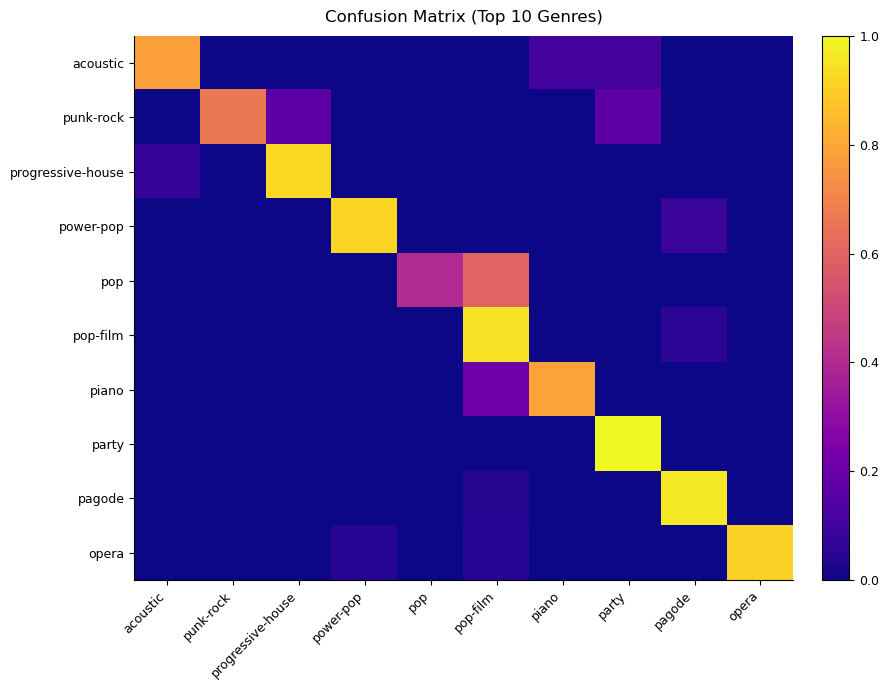

In [14]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# Top 10 clases más frecuentes
target_name = "track_genre"
top_labels = df[target_name].value_counts().head(10).index.tolist()

# Matriz de confusión
cm = confusion_matrix(Y_test, Y_pred, labels=top_labels)

# Normalización por filas
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm.astype(float), row_sums, where=row_sums != 0)

print("Confusion matrix shape:", cm_norm.shape)

# FIGURA CLEAN + COLORES MÁS SUAVES
plt.figure(figsize=(9, 7))
im = plt.imshow(cm_norm, cmap="plasma", aspect="auto", vmin=0)

cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=9)

plt.xticks(range(len(top_labels)), top_labels, rotation=45, ha='right', fontsize=9)
plt.yticks(range(len(top_labels)), top_labels, fontsize=9)

plt.title("Confusion Matrix (Top 10 Genres)", fontsize=12, pad=10)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Final Remarks

The experimental results demonstrate that numerical audio features provide a meaningful basis for music genre classification, despite the complexity of the task.

- The dataset is balanced across all 114 genre classes, avoiding class imbalance during training.
- Considerable overlap between genres makes accurate classification inherently challenging.
- Among the evaluated classifiers, **Random Forest** achieved the best overall predictive performance.
- Future improvements could include hyperparameter tuning, feature engineering, and the evaluation of additional machine learning models.